<a href="https://colab.research.google.com/github/hziqzmin/Machine-Learning-Practice/blob/main%2Froot/week03_decision_tree/obesity_decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount("/gdrive", force_remount=True)

Mounted at /gdrive


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn import tree
import graphviz

# 데이터 경로
file_path = "/gdrive/MyDrive/colab/week3/obesity.csv"
# 데이터 경로로부터 파일을 읽음 (pandas 라이브러리 사용)
datas = pd.read_csv(file_path)

# 데이터 출력 (데이터 형태 확인)
print(datas)

      Gender        Age    Height      Weight family_history_with_overweight  \
0     Female  21.000000  1.620000   64.000000                            yes   
1     Female  21.000000  1.520000   56.000000                            yes   
2       Male  23.000000  1.800000   77.000000                            yes   
3       Male  27.000000  1.800000   87.000000                             no   
4       Male  22.000000  1.780000   89.800000                             no   
...      ...        ...       ...         ...                            ...   
2106  Female  20.976842  1.710730  131.408528                            yes   
2107  Female  21.982942  1.748584  133.742943                            yes   
2108  Female  22.524036  1.752206  133.689352                            yes   
2109  Female  24.361936  1.739450  133.346641                            yes   
2110  Female  23.664709  1.738836  133.472641                            yes   

     FAVC  FCVC  NCP       CAEC SMOKE  

In [ ]:
# 범주형 데이터를 수치형 데이터로 자동 변환해주는 라이브러리
label_encoder = LabelEncoder()

# 7단계 비만 단계를 비만 여부(이진 분류: Normal vs Obesity)로 변환
obesity_types = ['Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']
datas['NObeyesdad'] = datas['NObeyesdad'].apply(lambda x: 'Obesity' if x in obesity_types else 'Normal')

# 정답 클래스 이름 ('Normal', 'Obesity')
target_names = label_encoder.fit(datas['NObeyesdad']).classes_
print("target_names : {}".format(target_names))

datas['Gender'] = label_encoder.fit_transform(datas['Gender'])
datas['family_history_with_overweight'] = label_encoder.fit_transform(datas['family_history_with_overweight'])
datas['FAVC'] = label_encoder.fit_transform(datas['FAVC'])
datas['CAEC'] = label_encoder.fit_transform(datas['CAEC'])
datas['SMOKE'] = label_encoder.fit_transform(datas['SMOKE'])
datas['SCC'] = label_encoder.fit_transform(datas['SCC'])
datas['CALC'] = label_encoder.fit_transform(datas['CALC'])
datas['MTRANS'] = label_encoder.fit_transform(datas['MTRANS'])
datas['NObeyesdad'] = label_encoder.fit_transform(datas['NObeyesdad'])

# 데이터 출력 (데이터 포맷 변환 후 결과 확인)
print(datas)

target_names : ['Normal' 'Obesity']
      Gender        Age    Height      Weight  family_history_with_overweight  \
0          0  21.000000  1.620000   64.000000                               1   
1          0  21.000000  1.520000   56.000000                               1   
2          1  23.000000  1.800000   77.000000                               1   
3          1  27.000000  1.800000   87.000000                               0   
4          1  22.000000  1.780000   89.800000                               0   
...      ...        ...       ...         ...                             ...   
2106       0  20.976842  1.710730  131.408528                               1   
2107       0  21.982942  1.748584  133.742943                               1   
2108       0  22.524036  1.752206  133.689352                               1   
2109       0  24.361936  1.739450  133.346641                               1   
2110       0  23.664709  1.738836  133.472641                            

In [ ]:
# 입력 데이터와 정답 데이터로 분리
x_data, y_data = datas.drop(['NObeyesdad','Height','Weight'], axis=1), datas['NObeyesdad']

# 분리 결과 확인
print(x_data)
print()
print(y_data)

      Gender        Age  family_history_with_overweight  FAVC  FCVC  NCP  \
0          0  21.000000                               1     0   2.0  3.0   
1          0  21.000000                               1     0   3.0  3.0   
2          1  23.000000                               1     0   2.0  3.0   
3          1  27.000000                               0     0   3.0  3.0   
4          1  22.000000                               0     0   2.0  1.0   
...      ...        ...                             ...   ...   ...  ...   
2106       0  20.976842                               1     1   3.0  3.0   
2107       0  21.982942                               1     1   3.0  3.0   
2108       0  22.524036                               1     1   3.0  3.0   
2109       0  24.361936                               1     1   3.0  3.0   
2110       0  23.664709                               1     1   3.0  3.0   

      CAEC  SMOKE      CH2O  SCC       FAF       TUE  CALC  MTRANS  
0        2      0 

In [ ]:
# Decision tree 모델 학습 ()
decision_tree = tree.DecisionTreeClassifier(criterion = 'entropy', max_depth = 3)
train_result = decision_tree.fit(x_data, y_data)

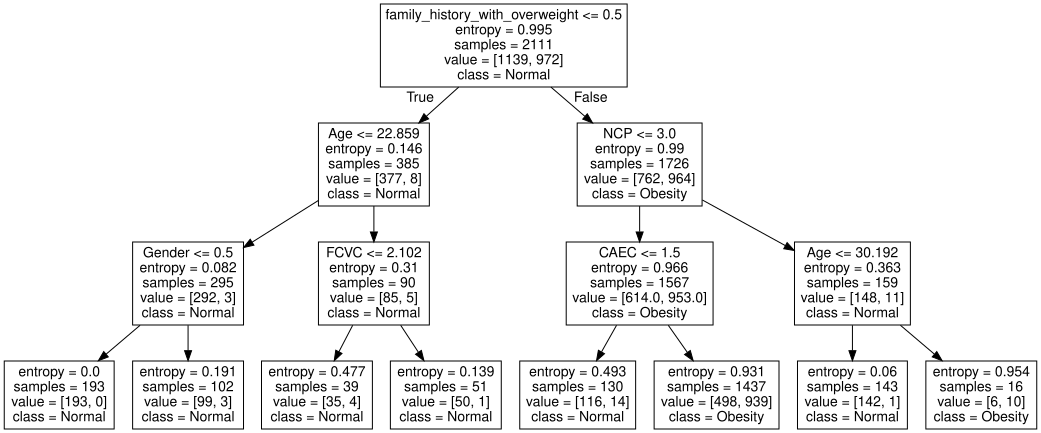

In [ ]:
# 학습 결과 확인 (graphviz 라이브러리 사용)
graph = graphviz.Source(tree.export_graphviz(train_result, out_file=None,
                                             feature_names=x_data.columns,
                                             class_names=target_names))
graph

In [ ]:
# 학습한 모델을 사용하여 예측
predict_result = decision_tree.predict(x_data)

# 예측 결과 출력 (실제 정답을 맞춘 경우 True로 표시됨)
print(predict_result == y_data)

0       False
1       False
2       False
3        True
4        True
        ...  
2106     True
2107     True
2108     True
2109     True
2110     True
Name: NObeyesdad, Length: 2111, dtype: bool
